# Logistische Regression

* Idee
    * Ja/Nein Betrachtung einer Fragestellung
    * Definition 
        * 0 = Nein
        * 1 = Ja
* Mathematisch:
    * Basierend auf linearer Regression 
    * Ausgabe wandeln in Werte zwischen 0 und 1

## Sigmoid Funktion

<Axes: >

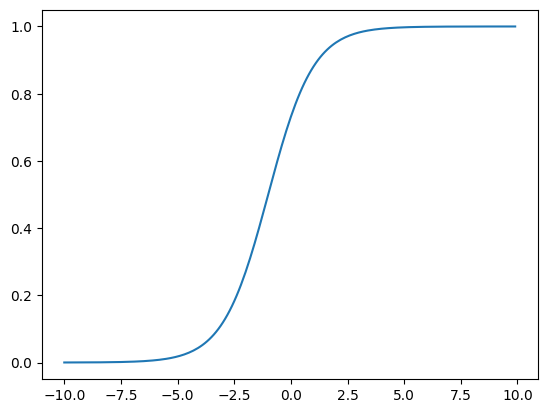

In [47]:
import numpy as np
import seaborn as sns

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

a = 1 # bestimmt wie Steil der Anstieg ist
b = 1 # bestimmt die Verschiebung entlang der x-Achse
 
xs = np.arange(-10, 10, 0.1)
ys = sigmoid(a * xs + b)

sns.lineplot(x = xs, y = ys)

### Idee

Der Zahlenbereich (z.B. aus der linearen Regression), oben im Beispiel von -10 bis 10 wird auf den Zahlenbereich 0 bis 1 reduziert

## Diabetes Beispiel

* Daten aus Indien, nur weibliche Patienten

In [48]:
import pandas as pd

df = pd.read_csv("./data/Diabetes/diabetes.csv") 

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [49]:
len(df)

768

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[["BMI", "Age"]]
y = df["Outcome"] # 0 = kein Diabetes, 1 = Diabetes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [51]:
print(model.predict(X_test))

[0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0
 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0
 0 1 1 0 1 0]


In [52]:
model.score(X_test, y_test) # andere Berechnung als beim Bestimmtheitsmaß R²

0.6753246753246753

In [53]:
y_test_pred = model.predict(X_test)

print(y_test_pred == y_test) # gibt für jede Vorhersage an, ob sie korrekt war (True) oder nicht (False)

253     True
479     True
722    False
732     True
283    False
       ...  
154     True
435     True
715    False
53      True
390     True
Name: Outcome, Length: 154, dtype: bool


In [54]:
y_test

253    0
479    0
722    1
732    1
283    1
      ..
154    1
435    1
715    1
53     1
390    0
Name: Outcome, Length: 154, dtype: int64

In [55]:
print(np.mean(y_test_pred == y_test)) # model.score() macht im Hintergrund genau das

0.6753246753246753


In [56]:
model.predict_proba?

Signature: model.predict_proba(X)
Docstring:
Probability estimates.

The returned estimates for all classes are ordered by the
label of classes.

For a multi_class problem, if multi_class is set to be "multinomial"
the softmax function is used to find the predicted probability of
each class.
Else use a one-vs-rest approach, i.e. calculate the probability
of each class assuming it to be positive using the logistic function
and normalize these values across all the classes.

Parameters
----------
X : array-like of shape (n_samples, n_features)
    Vector to be scored, where `n_samples` is the number of samples and
    `n_features` is the number of features.

Returns
-------
T : array-like of shape (n_samples, n_classes)
    Returns the probability of the sample for each class in the model,
    where classes are ordered as they are in ``self.classes_``.
File:      ~/anaconda3/envs/ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py
Type:      method

In [60]:
print(model.predict(X_test))
print("---")
print(model.classes_)
model.predict_proba(X_test) # gibt für jede Vorhersage die Wahrscheinlichkeiten aus

[0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0
 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0
 0 1 1 0 1 0]
---
[0 1]


array([[0.67341211, 0.32658789],
       [0.50616863, 0.49383137],
       [0.67602703, 0.32397297],
       [0.45663102, 0.54336898],
       [0.60212481, 0.39787519],
       [0.82462269, 0.17537731],
       [0.75350844, 0.24649156],
       [0.74371476, 0.25628524],
       [0.79464592, 0.20535408],
       [0.46494936, 0.53505064],
       [0.77970144, 0.22029856],
       [0.82782462, 0.17217538],
       [0.88920557, 0.11079443],
       [0.51387052, 0.48612948],
       [0.41362188, 0.58637812],
       [0.74695934, 0.25304066],
       [0.54258827, 0.45741173],
       [0.6320719 , 0.3679281 ],
       [0.77272597, 0.22727403],
       [0.86576545, 0.13423455],
       [0.43998743, 0.56001257],
       [0.87725035, 0.12274965],
       [0.63620854, 0.36379146],
       [0.59676336, 0.40323664],
       [0.76372185, 0.23627815],
       [0.449632  , 0.550368  ],
       [0.27282135, 0.72717865],
       [0.89939129, 0.10060871],
       [0.22477788, 0.77522212],
       [0.88514944, 0.11485056],
       [0.

In [ ]:
# [0.67341211, 0.32658789] => 67.34% kein Diabetes, 32.66% Diabetes

In [61]:
X_train

,BMI,Age
306,25.5,47
172,28.9,25
80,22.4,22
238,30.8,32
599,23.1,26
...,...,...
309,32.9,30
496,26.0,30
653,26.8,27
611,32.9,36


In [70]:
X_pred = pd.DataFrame([[25, 90]], columns=["BMI", "Age"])
print(model.predict(X_pred))
model.predict_proba(X_pred)

[1]


array([[0.32167639, 0.67832361]])